In [1]:
from google.colab import files
uploaded = files.upload()


Saving image_smpl.obj to image_smpl.obj


In [2]:
!pip install trimesh matplotlib scipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 4.0 MB/s eta 0:00:00


In [4]:
import trimesh
mesh = trimesh.load("image_smpl.obj")


In [7]:
def calculate_circumference(mesh, height_z):
    vertices = mesh.vertices
    faces = mesh.faces
    intersections = []

    for tri in faces:
        tri_vertices = vertices[tri]
        z_vals = tri_vertices[:, 2]
        if (z_vals.min() <= height_z <= z_vals.max()):
            for i in range(3):
                v1, v2 = tri_vertices[i], tri_vertices[(i+1)%3]
                if (v1[2] - height_z) * (v2[2] - height_z) < 0:
                    t = (height_z - v1[2]) / (v2[2] - v1[2])
                    intersection = v1 + t * (v2 - v1)
                    intersections.append(intersection[:2])

    intersections = np.array(intersections)

    if len(intersections) < 3:
        print("Not enough intersection points at this height.")
        return 0.0, intersections

    try:
        from scipy.spatial import ConvexHull
        hull = ConvexHull(intersections)
        loop_points = intersections[hull.vertices]
        circumference = np.sum(
            np.linalg.norm(loop_points - np.roll(loop_points, -1, axis=0), axis=1)
        )
    except Exception as e:
        print("ConvexHull failed:", e)
        return 0.0, intersections

    return circumference, loop_points


In [9]:
z_min, z_max = mesh.bounds[:,2]
print("Mesh Z range:", z_min, "to", z_max)



Mesh Z range: -0.19076708 to 0.38450861


In [10]:
import trimesh
import matplotlib.pyplot as plt

def visualize_mesh_with_slice(mesh, loop_points, height_z):
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    mesh.show(ax=ax)

    if loop_points is not None and len(loop_points) > 0:
        ax.plot(loop_points[:,0], loop_points[:,1], zs=height_z,
                color='red', linewidth=2)
    else:
        print("No valid slice found at this height.")

    plt.title("Waist Circumference Slice")
    plt.show()


In [17]:
for z in [0.05, 0.1, 0.15, 0.2]:
    c, _ = calculate_circumference(mesh, z)
    print(f"z={z:.2f}, circumference={c:.2f}")


z=0.05, circumference=4.18
z=0.10, circumference=4.09
z=0.15, circumference=2.41
z=0.20, circumference=1.80


In [20]:
for z in [0.22, 0.25, 0.30, 0.35]:
    c, _ = calculate_circumference(mesh, z)
    print(f"z={z:.2f}, circumference={c:.2f}")


z=0.22, circumference=1.85
z=0.25, circumference=1.93
z=0.30, circumference=2.02
z=0.35, circumference=0.29


Mesh Z range: -0.19076708 to 0.38450861
Waist circumference: 1.8024661810091243


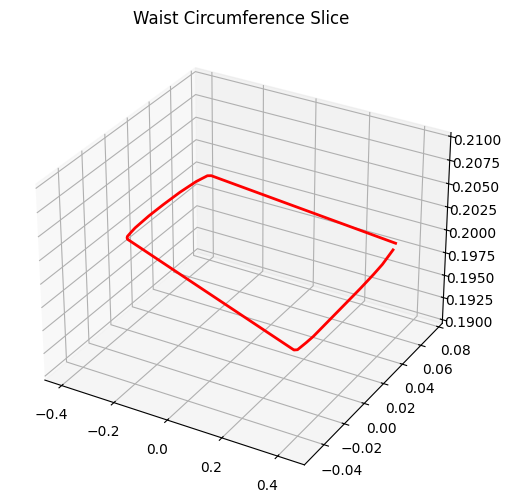

In [19]:
mesh = trimesh.load("image_smpl.obj")
z_min, z_max = mesh.bounds[:,2]
print("Mesh Z range:", z_min, "to", z_max)
height_z = 0.2
circumference, loop_points = calculate_circumference(mesh, height_z)
print("Waist circumference:", circumference)
visualize_mesh_with_slice(mesh, loop_points, height_z)